In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

In [6]:
! py main.py

--- Avvio Analisi Opzioni per AAPL ---
Recupero il prezzo attuale per AAPL
Prezzo Spot Rilevato per AAPL: $ 302.08
finding expiration dates...
Scadenza selezionata: 2026-09-18
inizio calcolo volatilità implicita per 146 contratti...
Converged in 3 iterations. Implied Volatility: 2.3610
Converged in 3 iterations. Implied Volatility: 2.5878
Converged in 3 iterations. Implied Volatility: 2.1149
Converged in 3 iterations. Implied Volatility: 1.9481
Converged in 3 iterations. Implied Volatility: 1.7710
Converged in 3 iterations. Implied Volatility: 1.6353
Converged in 3 iterations. Implied Volatility: 1.4217
Converged in 3 iterations. Implied Volatility: 1.2861
Converged in 6 iterations. Implied Volatility: 0.6041
Converged in 4 iterations. Implied Volatility: 1.0495
Converged in 3 iterations. Implied Volatility: 1.2064
Converged in 4 iterations. Implied Volatility: 0.8684
Converged in 3 iterations. Implied Volatility: 0.9810
Converged in 4 iterations. Implied Volatility: 0.8877
Converged i

Caricamento dati freschi dal file: superficie_iv_AAPL_2026-09-18.csv


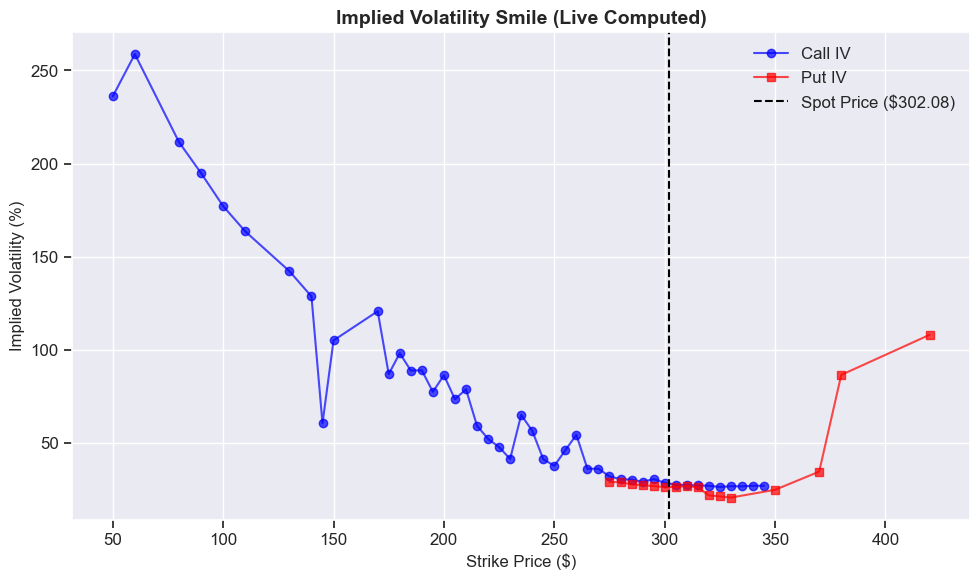

In [7]:
# Trova il file csv
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
latest_csv = max(csv_files, key=os.path.getctime)

print(f"Caricamento dati freschi dal file: {latest_csv}")
df = pd.read_csv(latest_csv)

# Creazione del grafico (Volatility Smile)
plt.figure(figsize=(10, 6))

calls = df[df['option_type'] == 'Call']
puts = df[df['option_type'] == 'Put']

plt.plot(calls['Strike'], calls['IV'] * 100, marker='o', linestyle='-', label='Call IV', color='blue', alpha=0.7)
plt.plot(puts['Strike'], puts['IV'] * 100, marker='s', linestyle='-', label='Put IV', color='red', alpha=0.7)

plt.title('Implied Volatility Smile (Live Computed)', fontsize=14, fontweight='bold')
plt.xlabel('Strike Price ($)', fontsize=12)
plt.ylabel('Implied Volatility (%)', fontsize=12)

# Linea dello spot price (se presente nel dataframe)
if 'Market_price' in df.columns:
    plt.axvline(x=df['Underlying_Price'].iloc[0], color='black', linestyle='--', label=f"Spot Price (${df['Underlying_Price'].iloc[0]:.2f})")


plt.legend()
plt.tight_layout()
plt.show()